Importing required libraries

In [183]:
#Importing libraries 
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import joblib
 
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix
)


In [184]:
#Adding path for the dataset
agri_data = pd.read_csv("/home/reva/Desktop/Irrigation_prediction/Crop_recommendationV2.csv")

Exploring dataset

In [185]:
#First 5 rows
agri_data.head()

,N,P,K,temperature,humidity,ph,rainfall,label,soil_moisture,soil_type,...,organic_matter,irrigation_frequency,crop_density,pest_pressure,fertilizer_usage,growth_stage,urban_area_proximity,water_source_type,frost_risk,water_usage_efficiency
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,29.446064,2,...,3.121395,4,11.743910,57.607308,188.194958,1,2.719614,3,95.649985,1.193293
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,12.851183,3,...,2.142021,4,16.797101,74.736879,70.963629,1,4.714427,2,77.265694,1.752672
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,29.363913,2,...,1.474974,1,12.654395,1.034478,191.976077,1,30.431736,2,18.192168,3.035541
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,26.207732,3,...,8.393907,1,10.864360,24.091888,55.761388,3,10.861071,3,82.818720,1.273341
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,28.236236,2,...,5.202285,3,13.852910,38.811481,185.259702,2,47.190777,3,25.466499,2.578671


In [186]:
#Column names 
agri_data.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label',
       'soil_moisture', 'soil_type', 'sunlight_exposure', 'wind_speed',
       'co2_concentration', 'organic_matter', 'irrigation_frequency',
       'crop_density', 'pest_pressure', 'fertilizer_usage', 'growth_stage',
       'urban_area_proximity', 'water_source_type', 'frost_risk',
       'water_usage_efficiency'],
      dtype='object')

In [187]:
#Additional info about dataset
agri_data.shape #2200 rows and 23 columns 
agri_data.dtypes
agri_data.info()
agri_data.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   N                       2200 non-null   int64  
 1   P                       2200 non-null   int64  
 2   K                       2200 non-null   int64  
 3   temperature             2200 non-null   float64
 4   humidity                2200 non-null   float64
 5   ph                      2200 non-null   float64
 6   rainfall                2200 non-null   float64
 7   label                   2200 non-null   object 
 8   soil_moisture           2200 non-null   float64
 9   soil_type               2200 non-null   int64  
 10  sunlight_exposure       2200 non-null   float64
 11  wind_speed              2200 non-null   float64
 12  co2_concentration       2200 non-null   float64
 13  organic_matter          2200 non-null   float64
 14  irrigation_frequency    2200 non-null   

,N,P,K,temperature,humidity,ph,rainfall,soil_moisture,soil_type,sunlight_exposure,...,organic_matter,irrigation_frequency,crop_density,pest_pressure,fertilizer_usage,growth_stage,urban_area_proximity,water_source_type,frost_risk,water_usage_efficiency
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,...,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655,20.151388,1.991364,8.570609,...,5.465652,3.515000,12.344959,49.850701,125.846403,1.999545,24.801013,2.003636,50.304701,2.990268
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389,5.793720,0.812263,1.999382,...,2.605294,1.697912,4.297494,28.886354,43.564527,0.818999,14.523975,0.812021,28.580352,1.139637
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267,10.024260,1.000000,5.000710,...,1.003338,1.000000,5.004341,0.038103,50.209990,1.000000,0.017756,1.000000,0.054911,1.002106
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686,15.179949,1.000000,6.904620,...,3.203903,2.000000,8.585734,24.379866,88.030737,1.000000,12.212594,1.000000,26.104674,2.051814
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624,20.088481,2.000000,8.609968,...,5.418049,4.000000,12.303616,49.982421,126.441536,2.000000,24.922548,2.000000,50.171934,2.968675
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508,25.255146,3.000000,10.220394,...,7.686417,5.000000,15.975567,74.681904,163.850536,3.000000,37.322761,3.000000,75.262676,3.968736
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117,29.997860,3.000000,11.991041,...,9.999990,6.000000,19.988474,99.983849,199.982166,3.000000,49.992046,3.000000,99.957274,4.997130


In [188]:
# Duplicate values 
agri_data.duplicated().any()

False

Missing values

In [189]:
# Missing values are none 
agri_data.isnull().sum().sum() #No null values

0

Graphs for analysis

<Axes: ylabel='Frequency'>

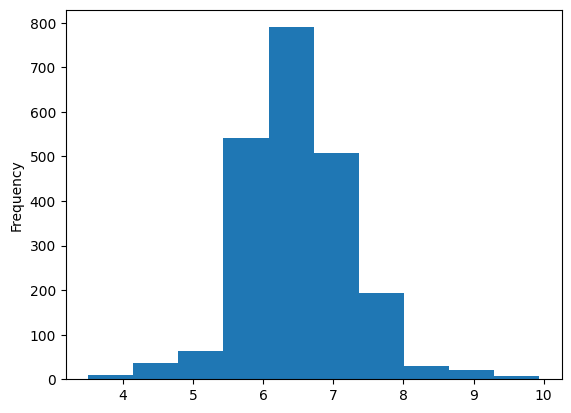

In [190]:
# Histogram of the pH
agri_data["ph"].plot(kind="hist")

In [191]:
#Mapping the soil type with appropriate values 

field_capacity_mapping = {1:12, 2: 28, 3: 40}
wilting_point_mapping = {1:5, 2: 14, 3: 22}
available_water_mapping = {1: 7, 2: 14, 3: 18}

agri_data["field_capacity"] = agri_data["soil_type"].map(field_capacity_mapping)
agri_data["wilting_point"] = agri_data["soil_type"].map(wilting_point_mapping)
agri_data["available_water"] = agri_data["soil_type"].map(available_water_mapping)

agri_data['allowed_depletion_p'] = agri_data['growth_stage'].map({1: 0.40, 2: 0.55, 3: 0.35})



In [192]:
#Calculating required metrics

#soil moisture trigger
agri_data["sm_trigger"] = agri_data["field_capacity"] - (agri_data["allowed_depletion_p"] * agri_data["available_water"])

#depletion ratio
agri_data["depletion_ratio"] = (agri_data["field_capacity"] - agri_data["soil_moisture"]) / (agri_data["field_capacity"] - agri_data["sm_trigger"])

#using the depletion ratio to decide whether irrigation is needed 
agri_data["irrigation_needed"] = (agri_data["depletion_ratio"] >= 1.0).astype(int)


In [193]:
#Do not want to use as input features
leaky_cols = ["soil_moisture", "field_capacity", "wilting_point","available_water", "sm_trigger", "depletion_ratio", "allowed_depletion_p"]

#Decision needs to be made
target_col = "irrigation_needed"

#List of columns which need to be included except the ones doing data leakage and the target columns
#Essentially the data such as N, P, K, humidity required to make the prediction
feature_cols = [c for c in agri_data.columns if c not in leaky_cols + [target_col]]

In [194]:
X = agri_data[feature_cols] #Input features
y = agri_data[target_col] #Output feature --> whether irrigation is needed

In [195]:
#Dropping columsn with object data type
X = X.drop(columns=["soil_category", "stage_category", "label"], errors="ignore")

Training the model

In [196]:
# Imports train_test_split from scikit
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, stratify=y, random_state=42
) #test is 10%  while preserving the proportions of split 

In [197]:
import xgboost as xgb
#XGB classifier 
clf = xgb.XGBClassifier(
    n_estimators=300, max_depth=8, learning_rate=0.01,
    eval_metric="error", random_state=42
) #n_estimators = number of trees, max_depth = number of leaves, smaller jumps


In [198]:
clf.fit(X_train, y_train) #fitting the classifier to te training dataset

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='error', feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

Evaluation

In [199]:
preds = clf.predict(X_test)
probs = clf.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, preds))
print("Precision:", precision_score(y_test, preds))
print("Recall:", recall_score(y_test, preds))
print("F1:", f1_score(y_test, preds))
print("ROC-AUC:", roc_auc_score(y_test, probs))
print(classification_report(y_test, preds))

Accuracy: 0.8863636363636364
Precision: 0.8571428571428571
Recall: 0.9391304347826087
F1: 0.896265560165975
ROC-AUC: 0.956024844720497
              precision    recall  f1-score   support

           0       0.93      0.83      0.87       105
           1       0.86      0.94      0.90       115

    accuracy                           0.89       220
   macro avg       0.89      0.88      0.89       220
weighted avg       0.89      0.89      0.89       220



Prediction of soil depletion rate

In [200]:
# Estimate Evapotranspiration (ET) demand 
agri_data['estimated_et'] = ((agri_data['temperature'] * 0.15) + (agri_data['sunlight_exposure'] * 0.20) + (agri_data['wind_speed'] * 0.05) - (agri_data['humidity'] * 0.10) - 
                             (agri_data['co2_concentration'] * 0.02)).clip(lower=0.1) # Prevent negative evaporative demand

agri_data['crop_factor'] = agri_data['growth_stage'].astype(float) * agri_data['crop_density']
agri_data['crop_water_demand'] = agri_data['estimated_et'] * agri_data['crop_factor']

# Final Depletion Rate Calculation (Losses minus Gains)
agri_data['irrigation_input'] = agri_data['irrigation_frequency'] * agri_data['water_usage_efficiency']
agri_data['depletion_rate'] = agri_data['crop_water_demand'] - agri_data['rainfall'] - agri_data['irrigation_input']

In [201]:
#Do not want to use as input features
leaky_cols = [
    "soil_moisture", "field_capacity", "wilting_point", "available_water", 
    "sm_trigger", "depletion_ratio", "allowed_depletion_p",
    "estimated_et", "crop_factor", "crop_water_demand", "irrigation_input",
    "irrigation_needed", "depletion_rate"
]
#Decision needs to be made on
target_col = "depletion_rate"

#List of columns which need to be included except the ones doing data leakage and the target columns
#Essentially the data such as N, P, K, humidity required to make the prediction
feature_cols = [c for c in agri_data.columns if c not in leaky_cols + [target_col]]

In [202]:
X = agri_data[feature_cols] #Input features
y = agri_data[target_col] #Output feature --> whether irrigation is needed

In [203]:
#Dropping columns which might cause overfitting
X = X.drop(columns=["soil_category", "stage_category", "label", "estimated_et", "crop_water_demand", "irrigation_input"], errors="ignore")


In [204]:
# Imports train_test_split from scikit
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
) #test is 10%  while preserving the proportions of split 

In [205]:
import xgboost as xgb
#XGB regressor for a continuous value 
rg = xgb.XGBRegressor(
    n_estimators=300, max_depth=8, learning_rate=0.01,
    eval_metric="rmse", random_state=42
) #n_estimators = number of trees, max_depth = number of leaves, smaller jumps

In [206]:
rg.fit(X_train, y_train) #fitting the classifier to te training dataset

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.01, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=8, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=300, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [207]:
preds_rg = rg.predict(X_test)
print("MAE: ", mean_absolute_error(y_test, preds_rg))
print("RMSE:", np.sqrt(mean_squared_error(y_test, preds_rg)))
print("R²:  ", r2_score(y_test, preds_rg))

MAE:  3.216723855919444
RMSE: 4.617369621942386
R²:   0.9930540184685565
